# 🏡 Exploratory Data Analysis — California Housing Dataset


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
from sklearn.datasets import fetch_california_housing

# Fetch the dataset
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. Data Overview

In [3]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))

Shape: (20640, 10)

Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [6]:
# Statistical summary of numeric columns
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
# Missing values per column
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct.round(2)}).sort_values("missing_count", ascending=False)

,missing_count,missing_pct
total_bedrooms,207,1.0
longitude,0,0.0
latitude,0,0.0
housing_median_age,0,0.0
total_rooms,0,0.0
population,0,0.0
households,0,0.0
median_income,0,0.0
median_house_value,0,0.0
ocean_proximity,0,0.0


In [8]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


**Observations so far:**
- `total_bedrooms` is the only column with missing values.
- All other numeric columns are complete.
- `ocean_proximity` is the only categorical (text) column.

## 3. Univariate Analysis

### 3.1 Numeric Feature Distributions

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

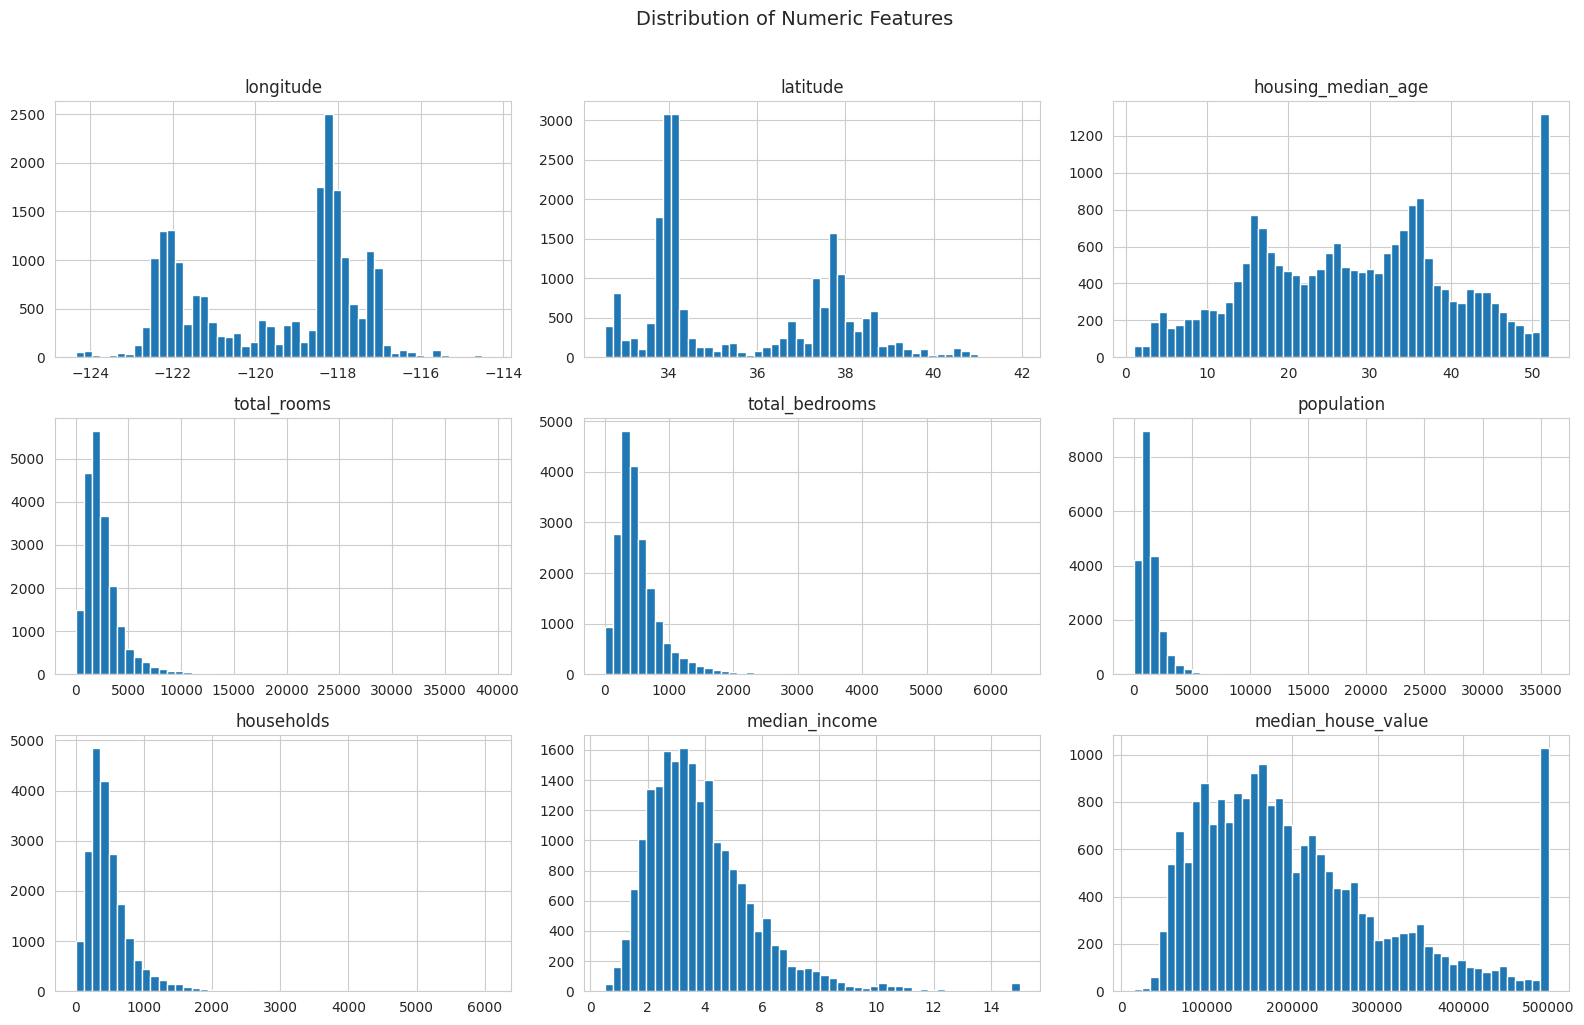

In [10]:
df[numeric_cols].hist(bins=50, figsize=(16, 10))
plt.suptitle("Distribution of Numeric Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 3.2 Boxplots — Spotting Outliers

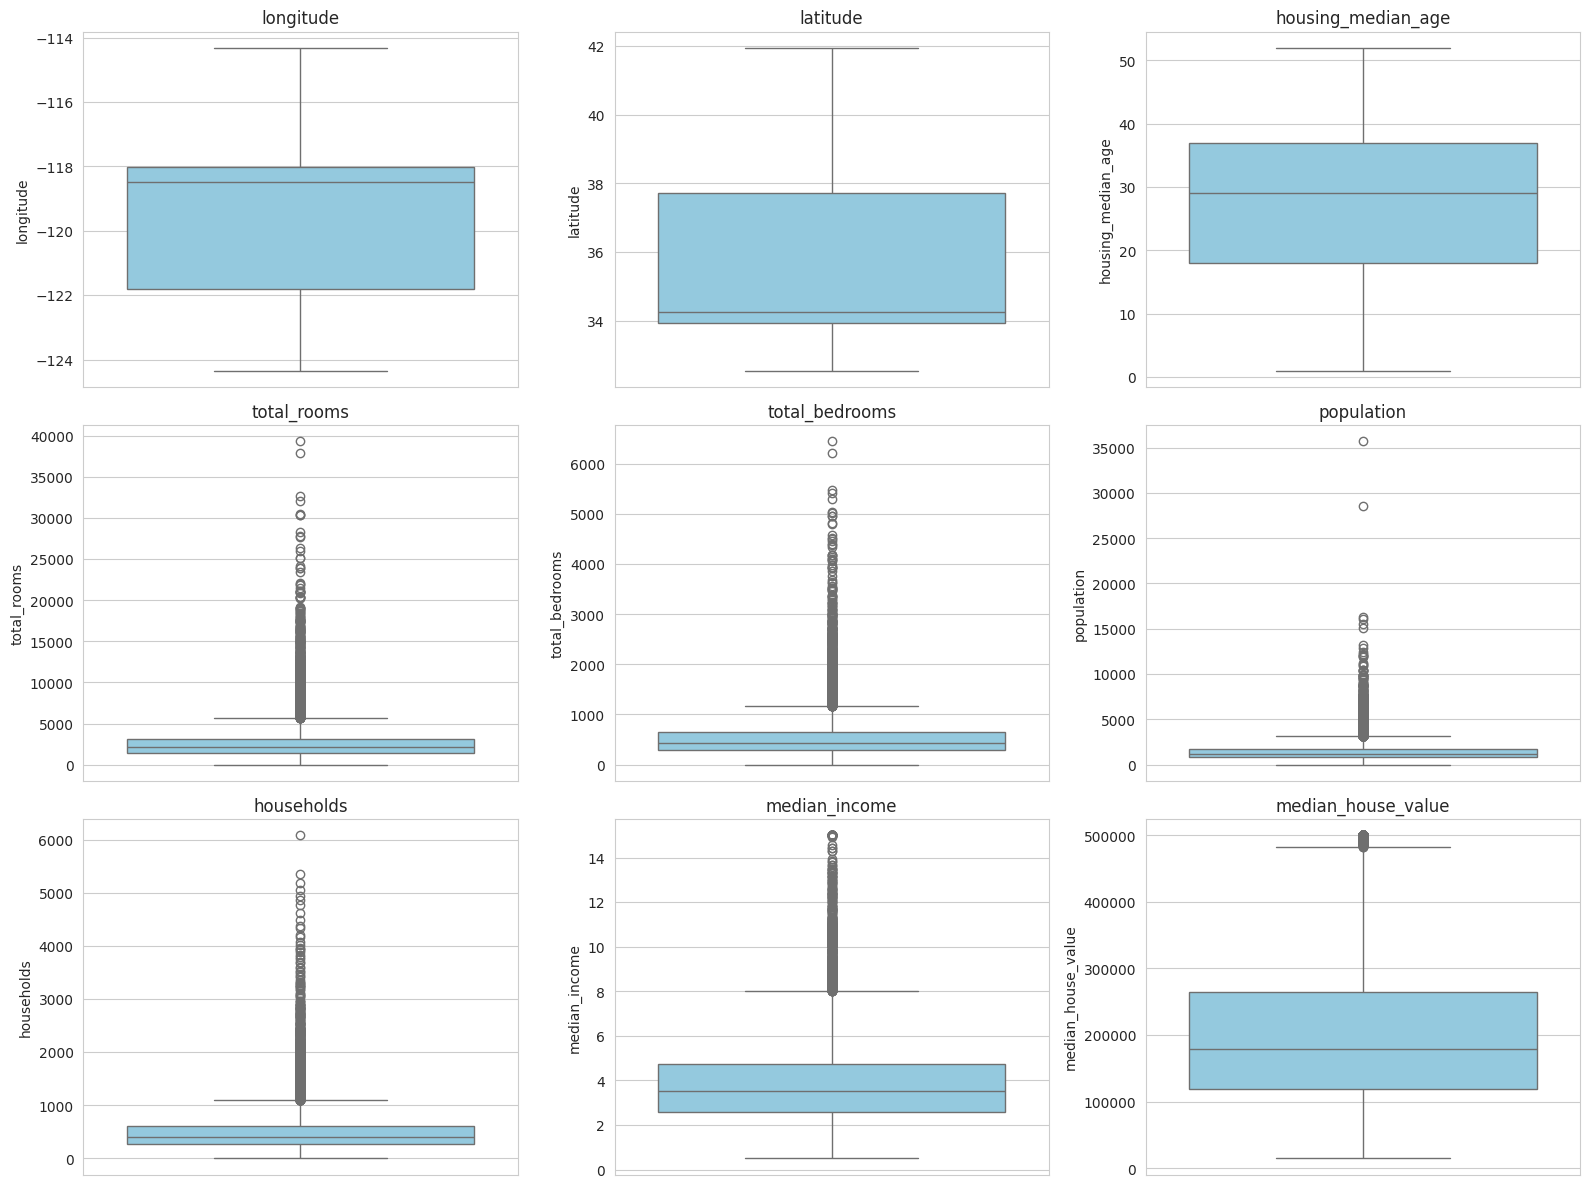

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col)

# Hide any unused subplots
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 3.3 Categorical Feature — `ocean_proximity`

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


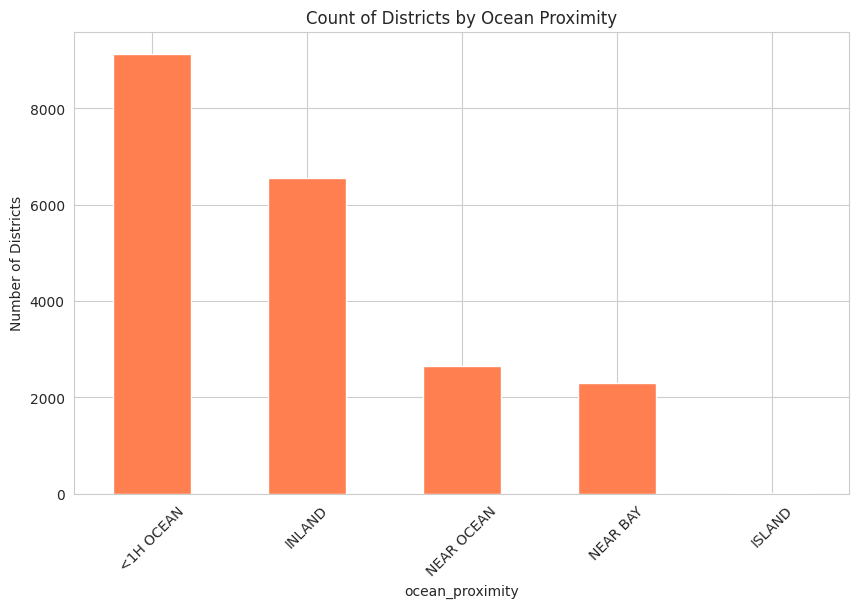

In [12]:
print(df["ocean_proximity"].value_counts())

df["ocean_proximity"].value_counts().plot(kind="bar", color="coral")
plt.title("Count of Districts by Ocean Proximity")
plt.ylabel("Number of Districts")
plt.xticks(rotation=45)
plt.show()

### 3.4 Target Variable — `median_house_value`

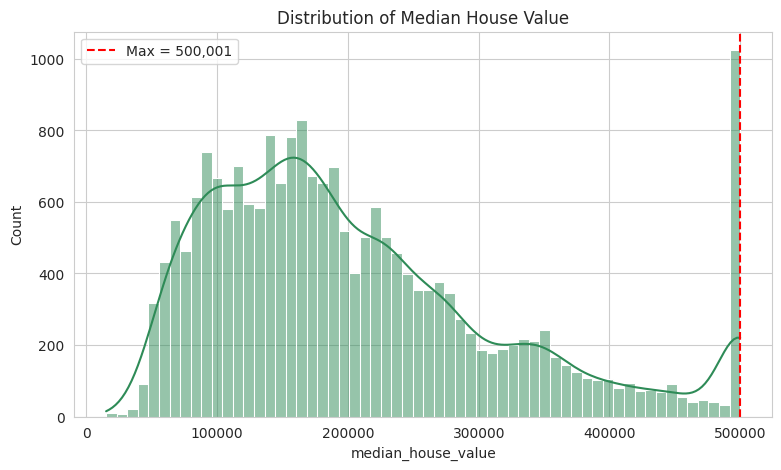

Districts at the max value: 965 (4.68% of data)


In [13]:
plt.figure(figsize=(9, 5))
sns.histplot(df["median_house_value"], bins=60, kde=True, color="seagreen")
plt.axvline(df["median_house_value"].max(), color="red", linestyle="--", label=f'Max = {df["median_house_value"].max():,.0f}')
plt.title("Distribution of Median House Value")
plt.legend()
plt.show()

# How many districts sit exactly at the max value (a sign of capping)?
capped = (df["median_house_value"] == df["median_house_value"].max()).sum()
print(f"Districts at the max value: {capped} ({capped/len(df)*100:.2f}% of data)")

**Note:** the spike at the right edge of the histogram suggests `median_house_value` was **capped** at $500,001 during data collection. This is a well-known quirk of this dataset — worth remembering if you later train a regression model on it, since it can distort predictions near the cap.

## 4. Bivariate / Relationship Analysis

### 4.1 Correlation Heatmap

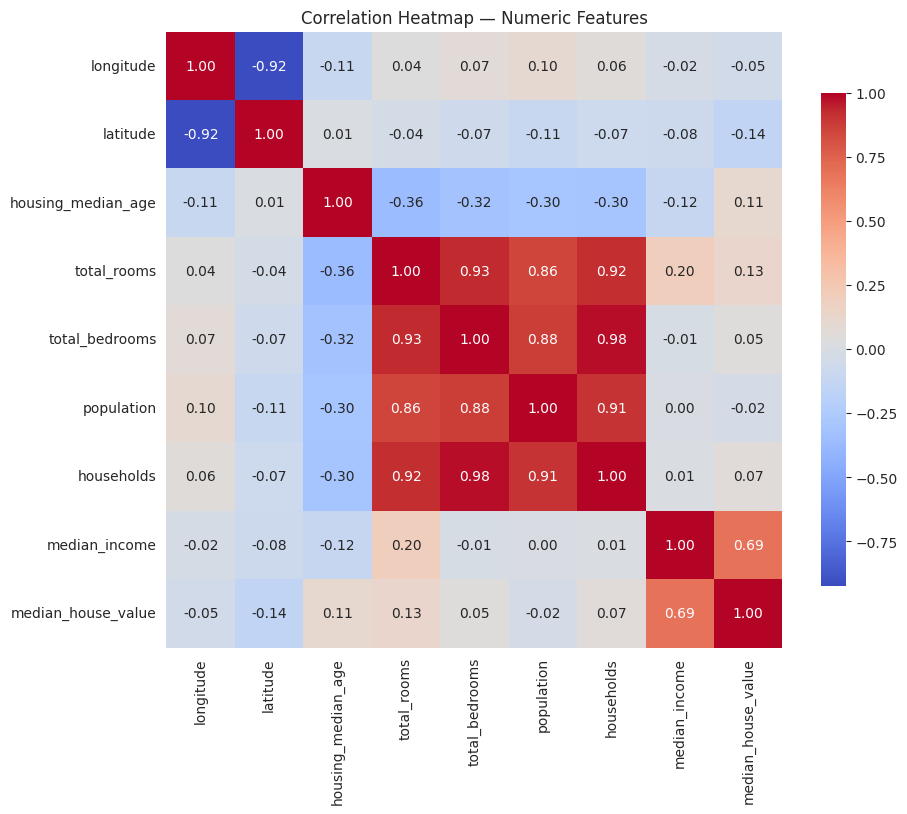

In [14]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap — Numeric Features")
plt.show()

In [15]:
# Correlation of every feature with the target, sorted
corr["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

### 4.2 Feature vs Target Scatter Plots

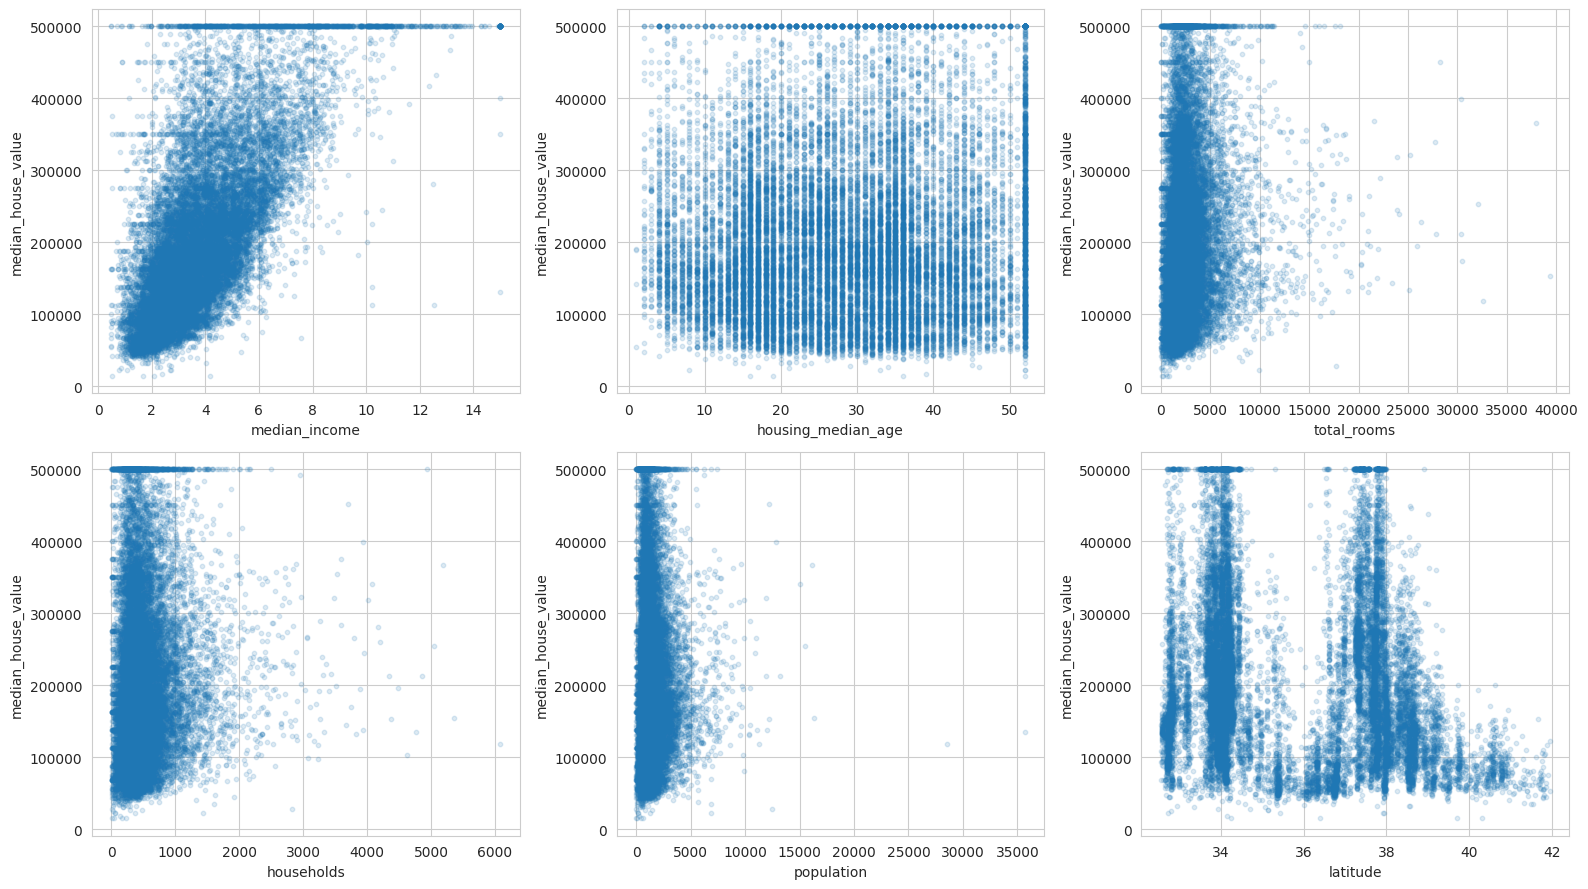

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

scatter_cols = ["median_income", "housing_median_age", "total_rooms", "households", "population", "latitude"]

for i, col in enumerate(scatter_cols):
    axes[i].scatter(df[col], df["median_house_value"], alpha=0.15, s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("median_house_value")

plt.tight_layout()
plt.show()

**`median_income` clearly stands out** — it has the strongest positive correlation with `median_house_value` and the clearest visual trend.

### 4.3 Target by Category — `ocean_proximity`

/tmp/ipykernel_16/2103068123.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="ocean_proximity", y="median_house_value", palette="Set2")


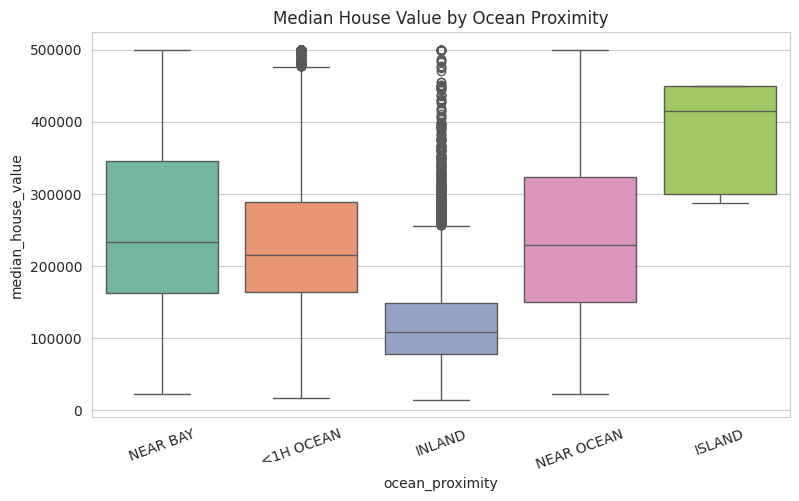

In [17]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value", palette="Set2")
plt.title("Median House Value by Ocean Proximity")
plt.xticks(rotation=20)
plt.show()

## 5. Geographic Visualization

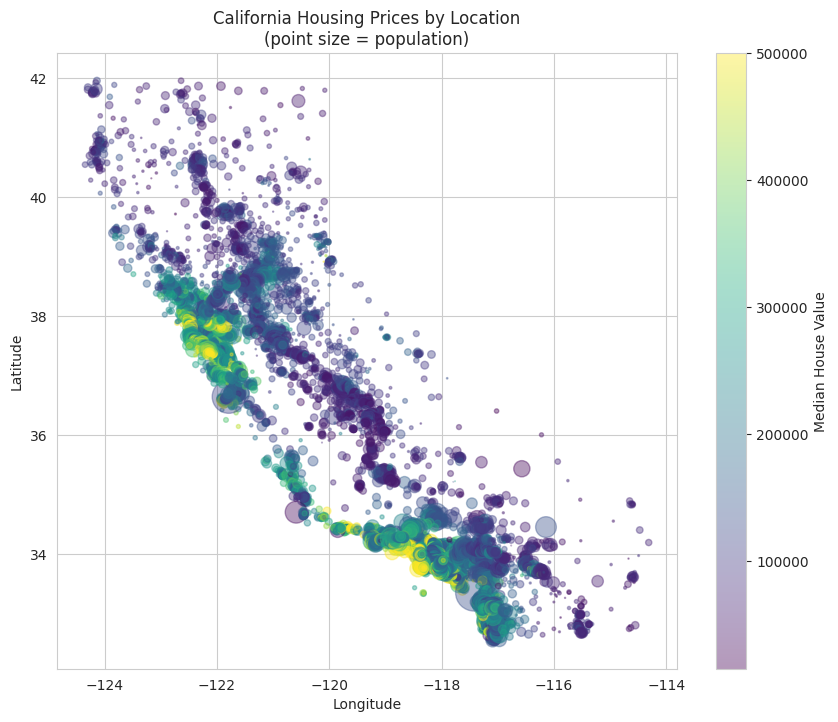

In [18]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df["longitude"], df["latitude"],
    c=df["median_house_value"], cmap="viridis",
    s=df["population"] / 50, alpha=0.4
)
plt.colorbar(scatter, label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Prices by Location\n(point size = population)")
plt.show()

This recreates the classic "map of California" view — bubble size shows district population, color shows house value. Prices are clearly higher along the coast (especially near the Bay Area and LA) and cheaper inland.

## 6. Missing Data & Outlier Handling

In [19]:
# Inspect rows with missing total_bedrooms
missing_rows = df[df["total_bedrooms"].isna()]
print(f"Rows with missing total_bedrooms: {len(missing_rows)}")
missing_rows.head()

Rows with missing total_bedrooms: 207


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY


In [20]:
# Simple imputation strategy: fill with the median
median_bedrooms = df["total_bedrooms"].median()
df["total_bedrooms"] = df["total_bedrooms"].fillna(median_bedrooms)

print("Remaining missing values:", df["total_bedrooms"].isna().sum())

Remaining missing values: 0


In [21]:
# Flag potential outliers using the IQR method
def iqr_outlier_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_summary = {}
for col in numeric_cols:
    low, high = iqr_outlier_bounds(df[col])
    n_outliers = ((df[col] < low) | (df[col] > high)).sum()
    outlier_summary[col] = n_outliers

pd.Series(outlier_summary, name="num_outliers").sort_values(ascending=False)

total_bedrooms        1306
total_rooms           1287
households            1220
population            1196
median_house_value    1071
median_income          681
longitude                0
latitude                 0
housing_median_age       0
Name: num_outliers, dtype: int64

`population`, `total_rooms`, and `households` have the most IQR-flagged outliers — these are typically a handful of unusually large/dense districts rather than data errors, so we keep them but note them for modeling.

## 7. Feature Engineering Exploration

In [22]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

df[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].describe()

,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20640.000000,20640.000000
mean,5.429000,0.213794,3.070655
std,2.474173,0.065248,10.386050
min,0.846154,0.037151,0.692308
25%,4.440716,0.175225,2.429741
50%,5.229129,0.203159,2.818116
75%,6.052381,0.240126,3.282261
max,141.909091,2.824675,1243.333333


In [23]:
engineered_cols = ["rooms_per_household", "bedrooms_per_room", "population_per_household", "median_house_value"]
corr_engineered = df[engineered_cols].corr()
corr_engineered["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
rooms_per_household         0.151948
population_per_household   -0.023737
bedrooms_per_room          -0.233303
Name: median_house_value, dtype: float64

`bedrooms_per_room` turns out to be **more informative** than the raw `total_bedrooms` / `total_rooms` counts — a lower ratio (fewer bedrooms relative to rooms) tends to associate with higher-value homes, likely reflecting larger, more spacious properties.

## 8. Multivariate View — Pair Plot

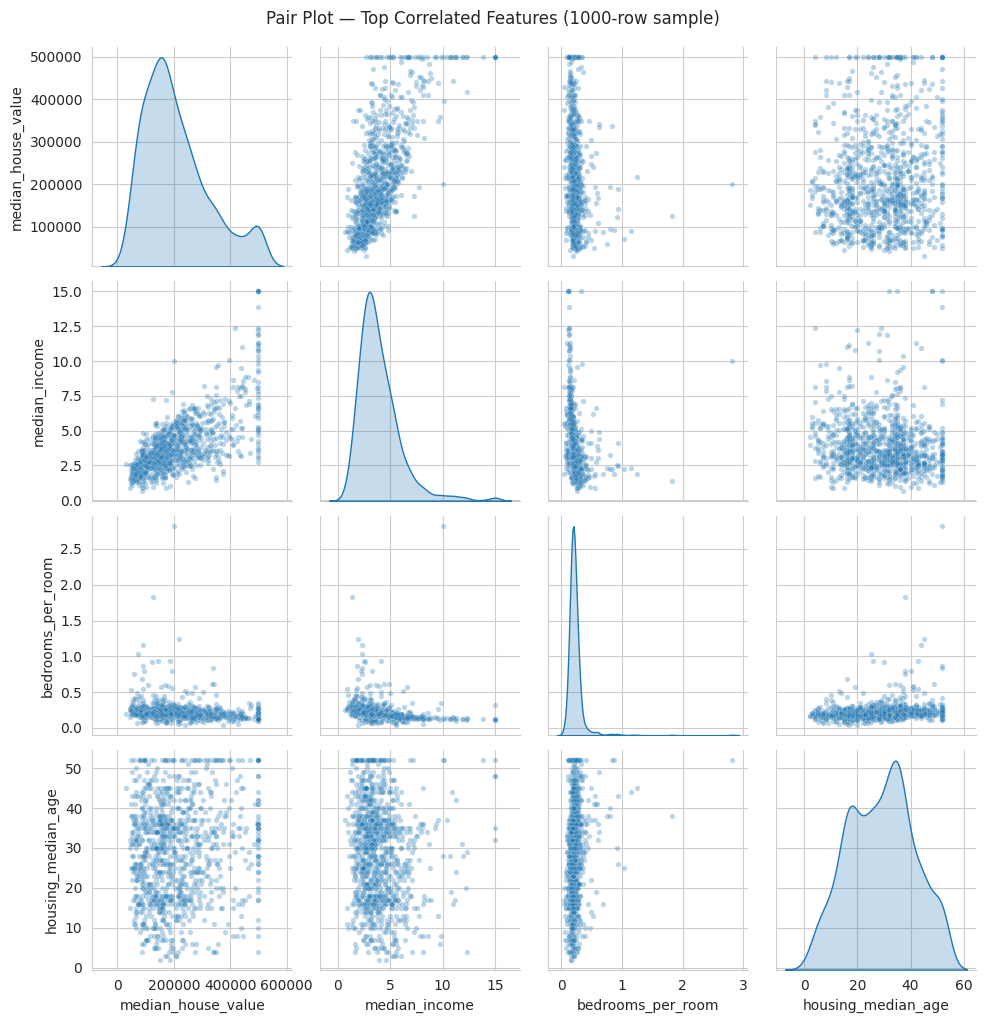

In [24]:
top_features = ["median_house_value", "median_income", "bedrooms_per_room", "housing_median_age"]

sns.pairplot(df[top_features].sample(1000, random_state=42), diag_kind="kde", plot_kws={"alpha": 0.3, "s": 15})
plt.suptitle("Pair Plot — Top Correlated Features (1000-row sample)", y=1.02)
plt.show()

## 9. Key Takeaways

- **`median_income` is the single strongest predictor** of `median_house_value` (correlation ≈ 0.69).
- **Location matters**: coastal districts (`NEAR BAY`, `NEAR OCEAN`, `<1H OCEAN`) tend to have higher median house values than `INLAND` districts.
- **`median_house_value` is capped** at $500,001 — a notable data quality quirk to account for in any downstream modeling.
- **`total_bedrooms`** was the only column with missing values (~1% of rows) — imputed with the median.
- **Engineered ratios** (`bedrooms_per_room`, `rooms_per_household`, `population_per_household`) carry more predictive signal than their raw component counts.
- **Outliers** exist mainly in `population`, `total_rooms`, and `households` — likely genuine high-density districts rather than data errors.

## 10. Suggested Next Steps

1. Handle the capped target values (e.g., remove or separately flag districts at the $500,001 cap).
2. Encode `ocean_proximity` (one-hot encoding) for use in ML models.
3. Try log-transforming skewed features (`total_rooms`, `population`, `households`) before modeling.
4. Use the engineered ratio features alongside raw features in a regression model and compare performance.
5. Consider spatial features (e.g., distance to nearest city center) to capture location effects more directly.